# Random Forest Crime Prediction Assignment

## Overview
In this assignment, you will use a **recent real-world crime dataset** to build a **Random Forest classification model**. You will explore the data, prepare it for modeling, train a classifier, evaluate the results, and interpret feature importance.

## Learning Goals
By the end of this assignment, you should be able to:

- explain the difference between **features** and a **target variable**
- prepare data for machine learning
- build a **Random Forest** classifier in Python
- evaluate a classification model using accuracy, a confusion matrix, and a classification report
- interpret **feature importance**
- connect model results to real-world patterns and possible limitations

## Important Note
In this notebook, you are **not predicting whether a crime will happen**.  
You are predicting:

> **Was an arrest made?** (`True` or `False`)

That means your model is learning patterns related to **arrest outcomes**, not crime occurrence itself.


## Step 1: Load the Data

We will use a recent subset of the Chicago crime dataset. The dataset is large, so we will pull a manageable sample for class use.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://data.cityofchicago.org/resource/ijzp-q8t2.csv?$limit=50000"
df = pd.read_csv(url)

df.head()

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,14175261,JK227794,2026-04-22T00:00:00.000,071XX S EAST END AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,False,True,...,7,43,08B,1188769.0,1857977.0,2026,2026-04-29T15:47:59.000,41.765354,-87.583658,"\n, \n(41.765353802, -87.583657537)"
1,14174595,JK226944,2026-04-22T00:00:00.000,055XX S DR MARTIN LUTHER KING JR DR,0880,THEFT,PURSE-SNATCHING,PARK PROPERTY,False,False,...,20,40,06,1179873.0,1868199.0,2026,2026-04-29T15:47:59.000,41.793612,-87.615951,"\n, \n(41.793612114, -87.615951236)"
2,14174913,JK227389,2026-04-22T00:00:00.000,117XX S BISHOP ST,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,STREET,False,False,...,21,53,07,1168779.0,1826815.0,2026,2026-04-29T15:47:59.000,41.680295,-87.657823,"\n, \n(41.680295342, -87.657823075)"
3,14180706,JK234455,2026-04-22T00:00:00.000,085XX S INGLESIDE AVE,0460,BATTERY,SIMPLE,SCHOOL - PUBLIC GROUNDS,False,False,...,8,44,08B,NaN,NaN,2026,2026-04-29T15:47:59.000,NaN,NaN,NaN
4,14174742,JK227162,2026-04-22T00:00:00.000,117XX S MORGAN ST,0460,BATTERY,SIMPLE,SCHOOL - PUBLIC BUILDING,False,False,...,21,53,08B,1171767.0,1827035.0,2026,2026-04-29T15:47:59.000,41.680834,-87.646879,"\n, \n(41.680834251, -87.646879157)"


## Step 2: Explore the Data

Look at the structure of the dataset.

### Questions
1. What does each row represent? <br>
Each row represents a single crime, including details such as the type of crime, location, date, and whether an arrest was made, etc.

2. Which variables look potentially useful for prediction?<br>
Variables such as whether an arrest was made, as well as primary_type, description, and fbi_code. Also variables such as block, location_description, ward, community_area, latitude, and longitude may also be important, since arrest likelihood can vary by area. Additionally, variables like date, year, and domestic may influence outcomes based on timing and context.

3. Which variable appears to be the target for this assignment?<br>
Arrest- whether an arrest was made (True or False).

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    50000 non-null  int64  
 1   case_number           50000 non-null  object 
 2   date                  50000 non-null  object 
 3   block                 50000 non-null  object 
 4   iucr                  50000 non-null  object 
 5   primary_type          50000 non-null  object 
 6   description           50000 non-null  object 
 7   location_description  49785 non-null  object 
 8   arrest                50000 non-null  bool   
 9   domestic              50000 non-null  bool   
 10  beat                  50000 non-null  int64  
 11  district              50000 non-null  int64  
 12  ward                  50000 non-null  int64  
 13  community_area        50000 non-null  int64  
 14  fbi_code              50000 non-null  object 
 15  x_coordinate       

In [3]:
df.describe(include='all')

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
count,5.000000e+04,50000,50000,50000,50000,50000,50000,49785,50000,50000,...,50000.000000,50000.000000,50000,4.991100e+04,4.991100e+04,50000.0,50000,49911.000000,49911.000000,49911
unique,NaN,49992,26970,17168,285,30,269,110,2,2,...,NaN,NaN,25,NaN,NaN,NaN,114,NaN,NaN,33898
top,NaN,JK221489,2026-04-01T00:00:00.000,0000X N STATE ST,0486,THEFT,SIMPLE,STREET,False,False,...,NaN,NaN,06,NaN,NaN,NaN,2026-03-14T15:41:39.000,NaN,NaN,"\n, \n(41.803671998, -87.703846021)"
freq,NaN,3,37,138,4133,10863,6457,13776,42367,40277,...,NaN,NaN,12689,NaN,NaN,NaN,20386,NaN,NaN,85
mean,1.410892e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23.050440,35.899020,NaN,1.165653e+06,1.887625e+06,2026.0,NaN,41.847219,-87.667584,NaN
std,6.179738e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.963767,21.352461,NaN,1.615919e+04,3.114075e+04,0.0,NaN,0.085636,0.058839,NaN
min,2.902700e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,1.000000,NaN,1.094587e+06,1.814793e+06,2026.0,NaN,41.647039,-87.927365,NaN
25%,1.411613e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.000000,22.000000,NaN,1.154474e+06,1.860774e+06,2026.0,NaN,41.773379,-87.708201,NaN
50%,1.413634e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23.000000,32.000000,NaN,1.167541e+06,1.894115e+06,2026.0,NaN,41.865194,-87.660388,NaN
75%,1.415571e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,34.000000,53.000000,NaN,1.176858e+06,1.910298e+06,2026.0,NaN,41.909781,-87.626460,NaN


## Step 3: Data Cleaning

We will keep a smaller set of variables for this assignment.

- `primary_type`: type of crime
- `arrest`: whether an arrest was made
- `domestic`: whether the incident was domestic-related
- `district`: police district
- `latitude`, `longitude`: location

Then we will remove rows with missing values.


In [4]:
df = df[['primary_type', 'arrest', 'domestic', 'district', 'latitude', 'longitude']]
df = df.dropna()

df.head()

,primary_type,arrest,domestic,district,latitude,longitude
0,BATTERY,False,True,3,41.765354,-87.583658
1,THEFT,False,False,2,41.793612,-87.615951
2,MOTOR VEHICLE THEFT,False,False,5,41.680295,-87.657823
4,BATTERY,False,False,5,41.680834,-87.646879
5,BATTERY,True,True,3,41.763151,-87.576235


### Short Response
Why might missing values cause problems in machine learning and mapping?<br>

Missing values can cause problems because many machine learning models cannot handle them, which may lead to errors or inaccurate predictions. In mapping, missing location data (latitude/longitude) makes it impossible to plot points correctly, resulting in incomplete or misleading visualizations.


## Step 4: Interactive Crime Map

Now that the data has been cleaned, we can build a map using latitude and longitude.

We are placing this **after data cleaning** because missing values in location fields can cause mapping tools to fail.

### Note
We will use `CartoDB positron` for the base map. This tile option often works better in notebook environments than the default map tiles.


In [5]:
import folium

m = folium.Map(
    location=[df['latitude'].mean(), df['longitude'].mean()],
    zoom_start=11,
    tiles="CartoDB positron"
)

sample_df = df.sample(1000, random_state=42)

for _, row in sample_df.iterrows():
    color = "red" if row['arrest'] else "blue"
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2,
        color=color,
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

m

### Interpretation Questions
1. Do crime points appear evenly spread out, or do they cluster in certain areas?<br>
Crime points are fairly spread out but show some clustering in certain areas.

2. Do you see any visible differences between arrest and non-arrest locations? <br>
There are more non-arrest (blue) points, and arrests (red) are scattered with no clear location-based pattern.

3. If location turns out to be important later, does this map help explain why?<br>
Yes, the map shows some clustering of crimes, suggesting that location may influence arrest likelihood. At the same time, other variables should be looked to have a better understanding.


## Step 5: Arrest Rate by Crime Type

This chart helps you see which crime categories are more likely to lead to an arrest.


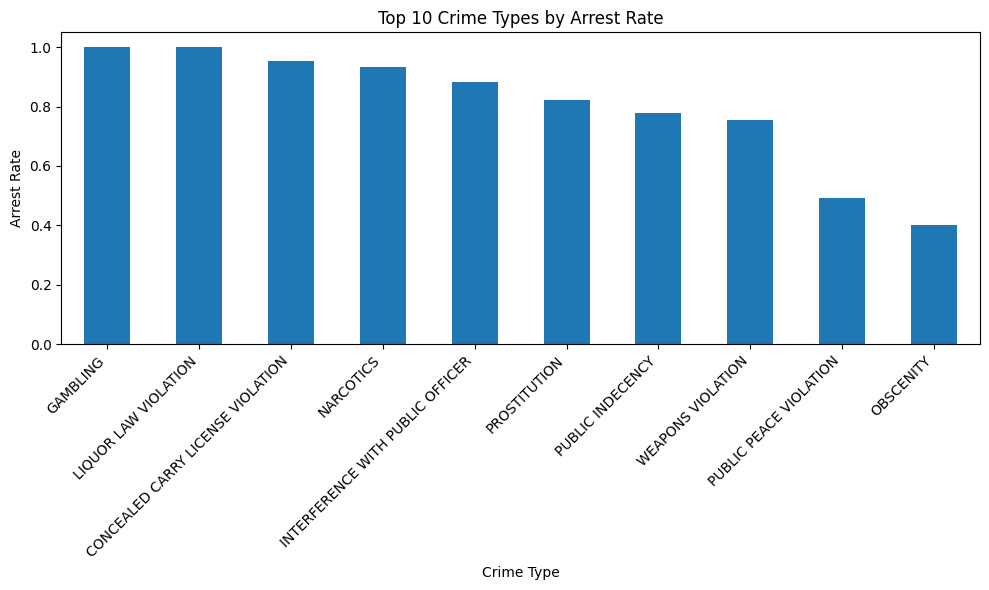

In [6]:
arrest_rates = df.groupby('primary_type')['arrest'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
arrest_rates.head(10).plot(kind='bar')
plt.title("Top 10 Crime Types by Arrest Rate")
plt.ylabel("Arrest Rate")
plt.xlabel("Crime Type")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretation Question
Which crime types seem most likely to lead to arrest? Does this surprise you? <br>

Crimes like gambling, liquor law violations, and concealed carry license violations have the highest arrest rates. This is not surprising because these crimes are often detected directly by police, making arrests more likely


## Step 6: Feature Engineering

Machine learning models need numeric input. Since `primary_type` and `district` are categorical, we will convert them into dummy variables.


In [7]:
df = pd.get_dummies(df, columns=['primary_type', 'district'], drop_first=True)
df.head()

,arrest,domestic,latitude,longitude,primary_type_ASSAULT,primary_type_BATTERY,primary_type_BURGLARY,primary_type_CONCEALED CARRY LICENSE VIOLATION,primary_type_CRIMINAL DAMAGE,primary_type_CRIMINAL SEXUAL ASSAULT,...,district_14,district_15,district_16,district_17,district_18,district_19,district_20,district_22,district_24,district_25
0,False,True,41.765354,-87.583658,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,41.793612,-87.615951,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,41.680295,-87.657823,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,41.680834,-87.646879,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,True,True,41.763151,-87.576235,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Step 7: Define Features and Target

Here is the key setup:

- `X` = the input features used to make predictions
- `y` = the target variable we want to predict

In this assignment:

> `y = arrest`

So the model predicts whether an arrest was made.


In [8]:
X = df.drop('arrest', axis=1)
y = df['arrest']

## Step 8: Train/Test Split

We split the data so the model trains on one portion and is evaluated on unseen data.


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 9: Train the Random Forest Model


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Step 10: Evaluate the Model

We will use:
- **Accuracy**
- **Confusion Matrix**
- **Classification Report**


In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8763898627667034

Confusion Matrix:
[[8036  403]
 [ 831  713]]

Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.95      0.93      8439
        True       0.64      0.46      0.54      1544

    accuracy                           0.88      9983
   macro avg       0.77      0.71      0.73      9983
weighted avg       0.86      0.88      0.87      9983



## Step 11: Feature Importance

Feature importance tells us which variables had the biggest influence on the model’s predictions.

A larger value means the model used that variable more heavily when making decisions.


In [12]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)
top_features

,0
latitude,0.323011
longitude,0.317275
primary_type_NARCOTICS,0.152272
primary_type_WEAPONS VIOLATION,0.063324
primary_type_INTERFERENCE WITH PUBLIC OFFICER,0.019366
primary_type_CRIMINAL TRESPASS,0.009877
domestic,0.009771
primary_type_CRIMINAL DAMAGE,0.008536
primary_type_MOTOR VEHICLE THEFT,0.007136
primary_type_BATTERY,0.006859


## Step 12: Visualize Feature Importance

This plot gives a clearer picture of what the model relied on most.


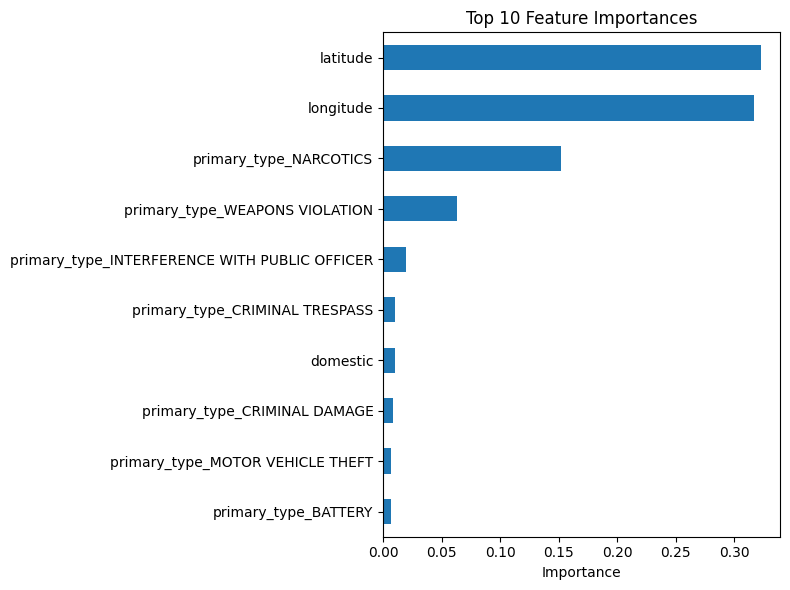

In [13]:
plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Interpretation Questions
1. Which features matter the most? <br>
latitude and landitude

2. Does the model seem to rely more on **location** or **crime type**? <br>
The model relies more on location, since latitude and longitude have the highest importance values compared to crime type variables.

3. What does that suggest about arrest outcomes in the dataset?<br>
This suggests that arrest outcomes are strongly influenced by where the crime occurs.

## Step 13: Cross Validation

Cross validation helps us check whether the model performs consistently across different subsets of the data.


In [14]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print("Cross-validation scores:", scores)
print("Average cross-validation score:", scores.mean())

Cross-validation scores: [0.87588901 0.87737928 0.87667802 0.87257063 0.87507514]
Average cross-validation score: 0.8755184153674349


## Step 14: Reflection

Write a short reflection that answers the following:

1. What does the model do well?<br>
The model performs well overall, with high accuracy (around 87–88%) and consistent cross-validation scores. It is especially good at predicting non-arrest cases.
2. What are its limitations?<br>
The dataset is imbalanced, with more non-arrests than arrests, which makes the model less accurate at predicting arrests. It may also reflect policing patterns rather than true crime behavior.
3. What does feature importance suggest about the strongest predictors of arrest?<br>
Feature importance shows that location (latitude and longitude) is the strongest predictor, followed by certain crime types like narcotics and weapons violations.
4. Why is it important to remember that this model predicts **arrest outcomes** rather than crime itself?<br>
Because arrest outcomes are influenced by factors like police presence and policies, the model reflects those patterns rather than whether crimes actually occur.
5. Should a model like this be used in real-world policing decisions? Why or why not?<br>
It should be used cautiously, as it may reinforce existing biases and inequalities. It can provide insights, but should not be the only factor in decision-making.
